Part A

Q1

Mean: 49.48658598099197
Variance: 96.60302768547191
Std Dev: 9.828683924385397


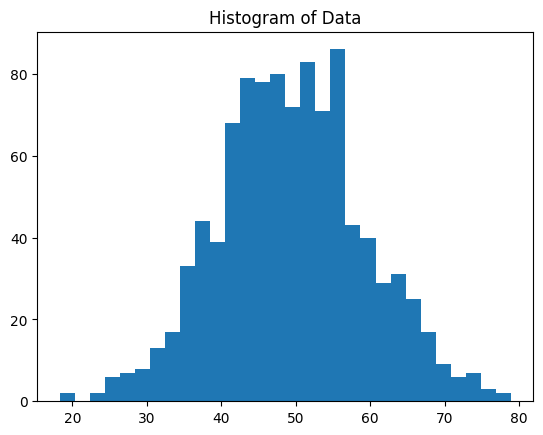

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data = np.random.normal(50, 10, 1000)  

total = 0
for x in data:
    total += x
mean = total / len(data)


sum_sq = 0
for x in data:
    sum_sq += (x - mean) ** 2
variance = sum_sq / len(data)



std_dev = variance ** 0.5


print("Mean:", mean)
print("Variance:", variance)
print("Std Dev:", std_dev)


plt.hist(data, bins=30)
plt.title("Histogram of Data")
plt.show()


Q2

In [2]:

z_data = []

for x in data:
    z = (x - mean) / std_dev
    z_data.append(z)

z_total = 0
for z in z_data:
    z_total += z
z_mean = z_total / len(z_data)


z_var_sum = 0
for z in z_data:
    z_var_sum += (z - z_mean) ** 2
z_var = z_var_sum / len(z_data)
z_std = z_var ** 0.5

print("Z Mean:", z_mean)
print("Z Std:", z_std)


Z Mean: -2.2564172752481683e-15
Z Std: 1.0000000000000007


Q3

In [3]:

marks = [45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 100, 30, 20]
total = 0
for m in marks:
    total += m
mean_m = total / len(marks)

sorted_marks = sorted(marks)
n = len(sorted_marks)

if n % 2 == 0:
    median = (sorted_marks[n//2] + sorted_marks[n//2 - 1]) / 2
else:
    median = sorted_marks[n//2]

sum_sq = 0
for m in marks:
    sum_sq += (m - mean_m) ** 2
var_m = sum_sq / len(marks)

std_m = var_m ** 0.5


print("Marks Mean:", mean_m)
print("Median:", median)
print("Variance:", var_m)
print("Std Dev:", std_m)
print("Outliers:")

for m in marks:
    z = (m - mean_m) / std_m
    if abs(z) > 2:
        print(m, "is an outlier")




Marks Mean: 63.46153846153846
Median: 65
Variance: 505.3254437869822
Std Dev: 22.47944491723455
Outliers:


Q4

In [4]:
mu0 = 50

z_stat = (mean - mu0) / (std_dev / (len(data) ** 0.5))

print("Z-stat:", z_stat)
if abs(z_stat) > 1.96:
    print("Reject H0")
else:
    print("Fail to reject H0")


Z-stat: -1.6518566424730012
Fail to reject H0


Q5

In [5]:
count_reject = 0
trials = 1000

for i in range(trials):
    
    sample = np.random.normal(50, 10, 1000)
    total = 0
    for x in sample:
        total += x
    m = total / len(sample)
    
    sum_sq = 0
    for x in sample:
        sum_sq += (x - m) ** 2
    var = sum_sq / len(sample)
    sd = var ** 0.5
    
    z = (m - 50) / (sd / (len(sample) ** 0.5))
    
    if abs(z) > 1.96:
        count_reject += 1


false_positive_rate = count_reject / trials

print("False Positive Rate:", false_positive_rate)
print("Expected alpha ~ 0.05")

False Positive Rate: 0.048
Expected alpha ~ 0.05


Part B


1. Normal vs Standard Normal Distribution

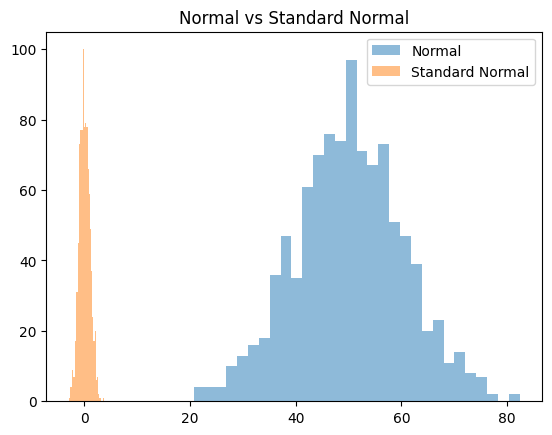

In [6]:
import numpy as np
import matplotlib.pyplot as plt


normal_data = np.random.normal(50, 10, 1000)
standard_data = np.random.normal(0, 1, 1000)

plt.hist(normal_data, bins=30, alpha=0.5, label="Normal")
plt.hist(standard_data, bins=30, alpha=0.5, label="Standard Normal")

plt.legend()
plt.title("Normal vs Standard Normal")
plt.show()

- Normal distribution can have any mean and std
- Standard normal distribution always has:
mean = 0
std = 1

- Shape of both is same (bell curve)
- Only difference is scale and center

2. Hypothesis Testing on Two Groups

In [7]:
g1 = np.random.normal(50, 10, 100)
g2 = np.random.normal(55, 10, 100)

sum1 = 0
for x in g1:
    sum1 += x
mean1 = sum1 / len(g1)

sum2 = 0
for x in g2:
    sum2 += x
mean2 = sum2 / len(g2)

print("Mean1:", mean1)
print("Mean2:", mean2)

diff = mean2 - mean1
print("Difference in mean:", diff)

Mean1: 49.34955865678389
Mean2: 56.369265407452374
Difference in mean: 7.019706750668483


Interpretation:

If difference is large, then groups are different
If difference is small, then maybe similar
In this case, group 2 mean is higher → so group 2 performs better

3. Theory Questions
When should we standardize data?
- When features have different scales
(example: age vs salary)
- Before using models like:
  KNN
  SVM
- Gradient descent based models

Why Z-score is important in ML?
- Converts data into same scale
- Mean becomes 0 and std becomes 1
- Helps model learn faster
- Prevents one feature dominating others
Useful for detecting outliers



Part C

Q1 — Difference between Normal and Standard Normal Distribution

Normal Distribution:
- Can have any mean and standard deviation
Example: mean = 50, std = 10
- Standard Normal Distribution:
 Mean = 0
 Standard deviation = 1

Simple difference:
- Shape is same (bell curve)
- Only center and scale are different

Q2 — Coding (Z-score Function)

In [8]:
def z_score(x, mean, std):
    return (x - mean) / std



data = [10, 20, 30, 40, 50]

total = 0
for i in data:
    total += i
mean = total / len(data)

sum_sq = 0
for i in data:
    sum_sq += (i - mean) ** 2
variance = sum_sq / len(data)
std = variance ** 0.5

z_values = []

for x in data:
    z = z_score(x, mean, std)
    z_values.append(z)

print("Mean:", mean)
print("Std:", std)
print("Z-scores:", z_values)

Mean: 30.0
Std: 14.142135623730951
Z-scores: [-1.414213562373095, -0.7071067811865475, 0.0, 0.7071067811865475, 1.414213562373095]


In [ ]:
Q3 — Hypothesis Testing

Hypothesis testing is a method to check assumptions using data.
Type of hypothesis
Null Hypothesis (H₀)
- Default assumption
- Example: mean = 50

Alternative Hypothesis (H₁)
- Opposite of null
- Example: mean ≠ 50

p-value
- Probability of getting result if H₀ is true
- Small p-value → reject H₀

Significance Level (α)
- Threshold (usually 0.05)
- If p-value < α → reject H₀
- If p-value > α → fail to reject

give me readme file for this and there are am.ipynb and pm.ipynb file